# Research Questions

The goal of this notebook is to answer the research question, mentioned in `01_start` notebook. The questions are categorized between, consistency, volume/strength and correlation questions. 

The goal of the research question is to gain insight on workout data, and to give an advise based on the results. The plots can also be added to the dashboard that will be created with PowerBI.

In [375]:
# import libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [376]:
df = pd.read_csv('cleaned_data.csv')

df['date'] = pd.to_datetime(df['date'])
df['date_short'] = pd.to_datetime(df['date_short'])

In [377]:
df.head()

,title,date,duration,exercise,weight,reps,set_type,date_short,body_weight,primary_muscle,secondary_muscle,volume,session_id
0,evening session,2026-03-29 19:33:12,01:55:18,full squat,80.0,8.0,normal_set,2026-03-29,69.6,quadriceps,"glutes, lower back",640.0,271
1,evening session,2026-03-29 19:33:12,01:55:18,full squat,90.0,8.0,normal_set,2026-03-29,69.6,quadriceps,"glutes, lower back",720.0,271
2,evening session,2026-03-29 19:33:12,01:55:18,full squat,90.0,8.0,normal_set,2026-03-29,69.6,quadriceps,"glutes, lower back",720.0,271
3,evening session,2026-03-29 19:33:12,01:55:18,lever seated leg press,120.0,6.0,normal_set,2026-03-29,69.6,quadriceps,glutes,720.0,271
4,evening session,2026-03-29 19:33:12,01:55:18,lever seated leg press,120.0,6.0,normal_set,2026-03-29,69.6,quadriceps,glutes,720.0,271


In [378]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4158 entries, 0 to 4157
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             4158 non-null   object        
 1   date              4158 non-null   datetime64[ns]
 2   duration          4158 non-null   object        
 3   exercise          4158 non-null   object        
 4   weight            4158 non-null   float64       
 5   reps              4158 non-null   float64       
 6   set_type          4158 non-null   object        
 7   date_short        4158 non-null   datetime64[ns]
 8   body_weight       4158 non-null   float64       
 9   primary_muscle    4158 non-null   object        
 10  secondary_muscle  4158 non-null   object        
 11  volume            4158 non-null   float64       
 12  session_id        4158 non-null   int64         
dtypes: datetime64[ns](2), float64(4), int64(1), object(6)
memory usage: 422.4+ KB


# Consistency 

### questions

1. How often does the user train per week?
2. On which days does the user train the most?
3. How does the workout frequency change over time?
4. At what time does the user workout the most?

## 1. How often does the user train per week on average?



### Table

In [379]:
# total number of workouts

for y in range(2024, 2027):
	dft = df[pd.to_datetime(df["date"]).dt.year == y]
	count_workouts = dft.groupby('date').size().count()

	# Total amount of days
	total_days = max(dft['date_short']) - min(dft['date_short'])
	# total amount of week
	total_weeks = total_days.days / 7
	
	# average amount of workouts per week
	average_workouts_per_week = count_workouts / total_weeks

	print(f" The user trains {average_workouts_per_week.round(1)} times per week on average in {y}.")

 The user trains 3.2 times per week on average in 2024.
 The user trains 3.3 times per week on average in 2025.
 The user trains 3.5 times per week on average in 2026.


In [380]:
df.groupby(df['date_short'].dt.to_period('M'))['session_id'].nunique()



date_short
2024-08     4
2024-09    15
2024-10    12
2024-11    13
2024-12    12
2025-01     9
2025-02    14
2025-03    14
2025-04    15
2025-05    20
2025-06    14
2025-07    21
2025-08     5
2025-09    16
2025-10    15
2025-11    18
2025-12    12
2026-01    11
2026-02    17
2026-03    15
Freq: M, Name: session_id, dtype: int64

In [381]:
weekly = (
    df.groupby(pd.Grouper(key="date", freq="W"))["session_id"]
    .nunique()
    .rename("workouts")
)
weekly = weekly.reset_index()
weekly.head()

,date,workouts
0,2024-09-01,4
1,2024-09-08,4
2,2024-09-15,3
3,2024-09-22,4
4,2024-09-29,3


In [382]:
monthly = (
    weekly.groupby(pd.Grouper(key='date', freq="ME"))["workouts"]
	.mean()
	.round(0)
	.rename('workouts')
)

monthly = monthly.reset_index()

### Plot

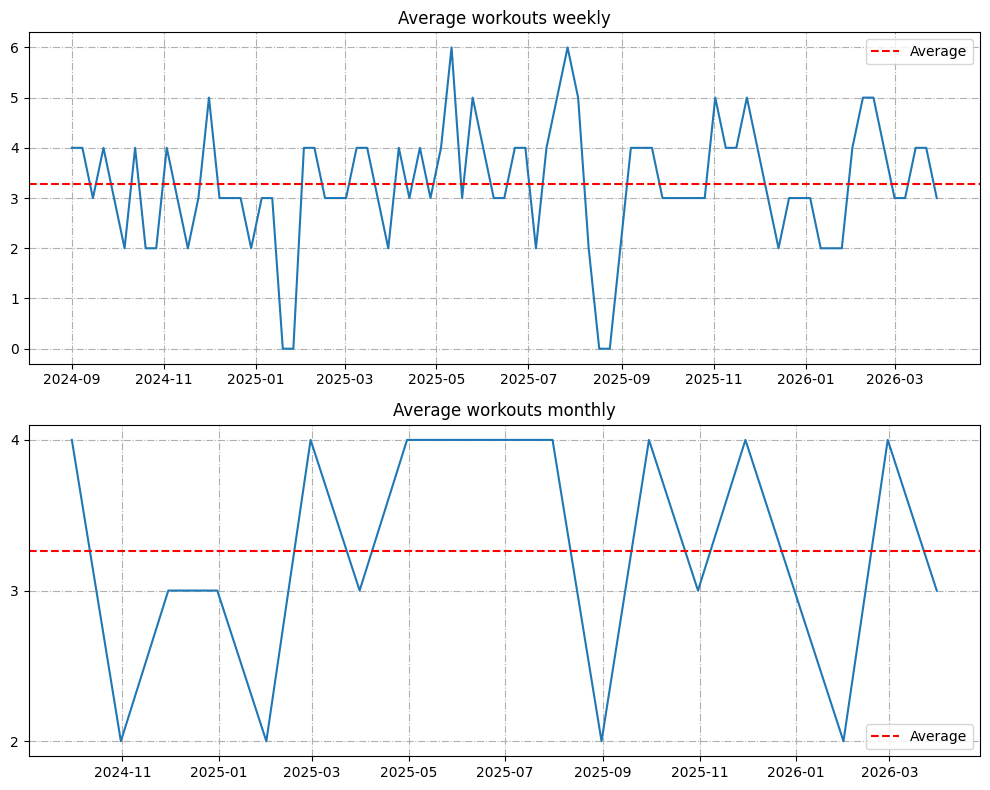

In [383]:
# create the plots in columns



fig, ax = plt.subplots(2, 1, figsize=(10, 8))

ax[0].plot(weekly['date'], weekly['workouts'])
ax[0].set_title("Average workouts weekly")
ax[0].set_yticks(range(weekly['workouts'].min().astype(int) , weekly['workouts'].max().astype(int)+1))
ax[0].grid(True, linestyle="dashdot")
ax[0].axhline(y=weekly['workouts'].mean(), color="red", label="Average", linestyle="dashed")
ax[0].legend()

ax[1].plot(monthly['date'], monthly['workouts'])
ax[1].set_title("Average workouts monthly")
ax[1].set_yticks(range(monthly['workouts'].min().astype(int) , monthly['workouts'].max().astype(int)+1))
ax[1].grid(True, linestyle="dashdot")
ax[1].axhline(y=monthly['workouts'].mean(), color="red", label="Average", linestyle="dashed")
ax[1].legend()

plt.tight_layout()
plt.show()



### Conclusion

## 2. On which days does the user train the most?

### Table

In [384]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]


weekday_2024 = (
	df.assign(weekday=df["date"].dt.day_name())[df['date_short'].dt.year == 2024]
	.groupby('weekday')['session_id']
	.nunique()
	.reindex(order, fill_value=0)
	.rename("workouts")
	)

weekday_2024 = weekday_2024.reset_index()

weekday_2025 = (
	df.assign(weekday=df["date"].dt.day_name())[df['date_short'].dt.year == 2025]
	.groupby('weekday')['session_id']
	.nunique()
	.reindex(order, fill_value=0)
	.rename("workouts")
	)

weekday_2025 = weekday_2025.reset_index()

weekday_2026 = (
	df.assign(weekday=df["date"].dt.day_name())[df['date_short'].dt.year == 2026]
	.groupby('weekday')['session_id']
	.nunique()
	.reindex(order, fill_value=0)
	.rename("workouts")
	)

weekday_2026 = weekday_2026.reset_index()
weekday_2026


,weekday,workouts
0,Monday,6
1,Tuesday,6
2,Wednesday,3
3,Thursday,8
4,Friday,7
5,Saturday,2
6,Sunday,11


### Plot

In [385]:
week_colors = [
    '#e63946', # Monday (Red)
    '#f4a261', # Tuesday (Sand)
    '#e9c46a', # Wednesday (Yellow)
    '#2a9d8f', # Thursday (Teal)
    '#264653', # Friday (Charcoal)
    '#457b9d', # Saturday (Steel Blue)
    '#1d3557'  # Sunday (Navy)
]

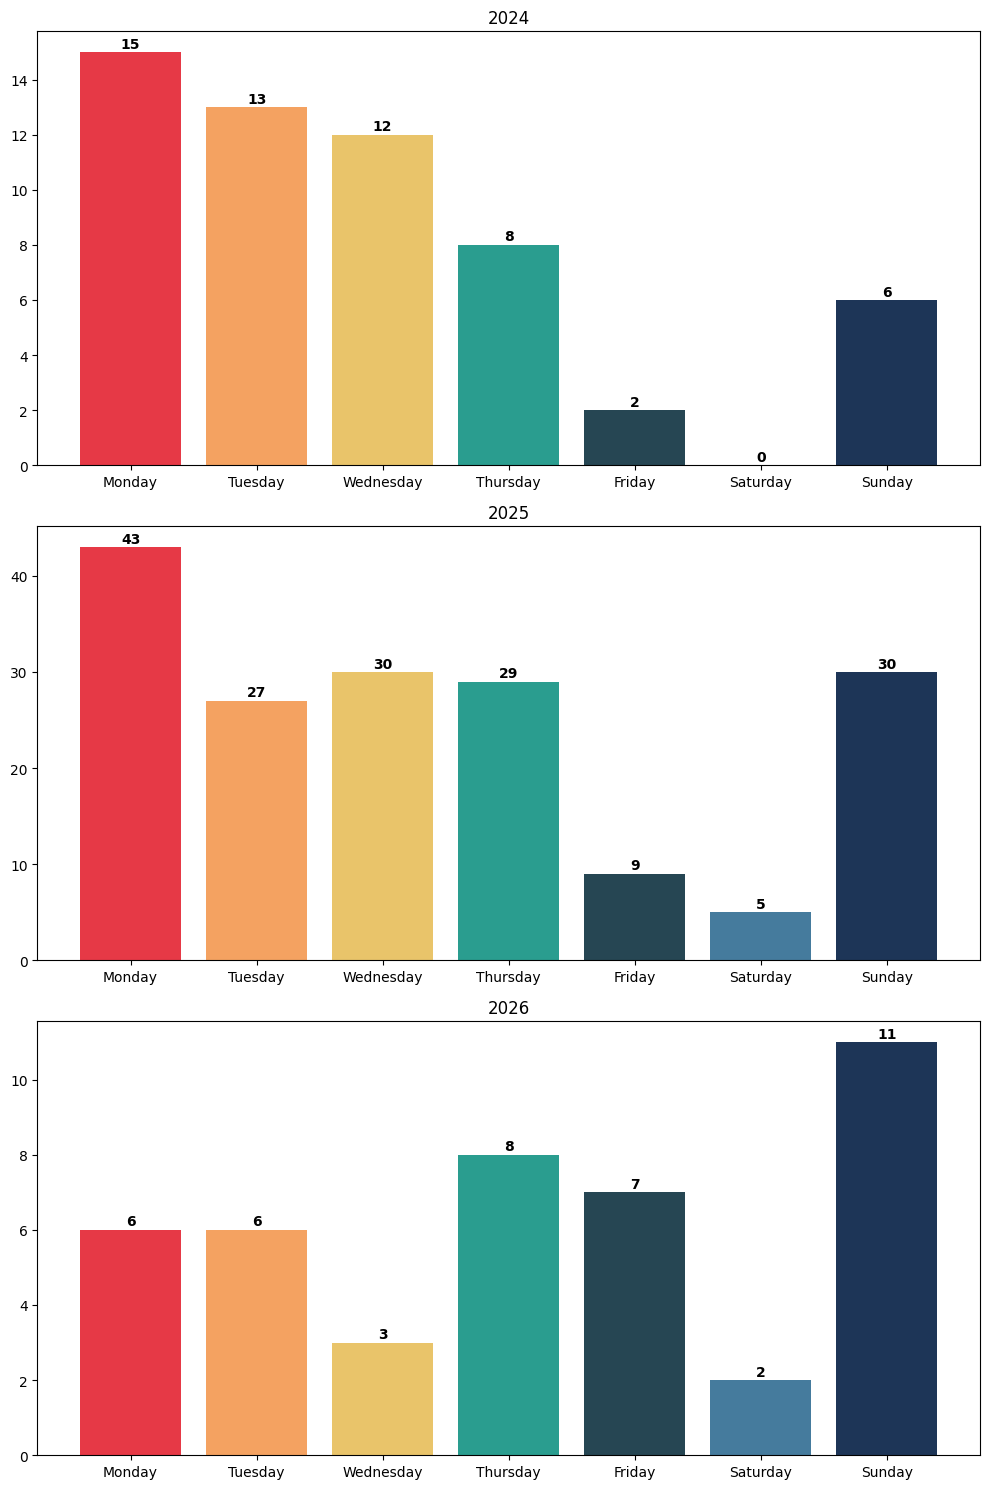

In [386]:
by_year = {2024: weekday_2024, 2025: weekday_2025, 2026: weekday_2026}

fig, axes = plt.subplots(3, 1, figsize=(10, 15))  

for i, year in enumerate(range(2024, 2027)):
    w = by_year[year]
    ax = axes[i]
    bars = ax.bar(x=w["weekday"], height=w["workouts"], color=week_colors)
    ax.bar_label(bars, padding=1, fontweight="bold")
    ax.set_title(str(year))

plt.tight_layout()


## 3. How does the workout frequency change over time?

### Table

In [412]:
weekly.head()

weekly1 = weekly.assign(cum_mean=weekly["workouts"].expanding().mean().round(1))
# Add this line before plotting
weekly1['moving_avg'] = weekly1['workouts'].rolling(window=8, min_periods=1).mean()
weekly1.head()

,date,workouts,cum_mean,moving_avg
0,2024-09-01,4,4.0,4.000000
1,2024-09-08,4,4.0,4.000000
2,2024-09-15,3,3.7,3.666667
3,2024-09-22,4,3.8,3.750000
4,2024-09-29,3,3.6,3.600000


### Plot

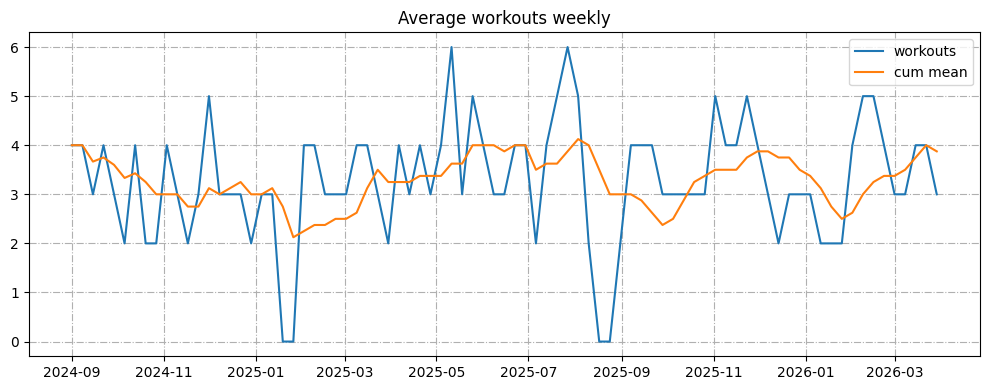

In [413]:
# create the plots in columns



fig, ax = plt.subplots( figsize=(10, 4))

ax.plot(weekly1['date'], weekly1[['workouts']], label="workouts")
ax.plot(weekly1['date'], weekly1[['moving_avg']], label="cum mean")
ax.set_title("Average workouts weekly")
ax.set_yticks(range(weekly1['workouts'].min().astype(int) , weekly1['workouts'].max().astype(int)+1))
ax.grid(True, linestyle="dashdot")
ax.legend()



plt.tight_layout()
plt.show()



### Conclusion

## 4. At what time does the user workout the most?

### Table


In [436]:
from os import access


starts = (
    df.groupby("session_id", as_index=False)["date"]
    .min()
    .rename(columns={"date": "session_start"})
)

starts["hour"] = starts["session_start"].dt.hour

by_hour = (
    starts.groupby("hour", as_index=False)
    .size()
    .rename(columns={"size": "sessions"})
    .sort_values("sessions", ascending=False)
	.sort_index()
)

by_hour

,hour,sessions
0,9,2
1,10,4
2,11,7
3,12,1
4,13,7
5,14,11
6,15,16
7,16,9
8,17,10
9,18,26


### Plot

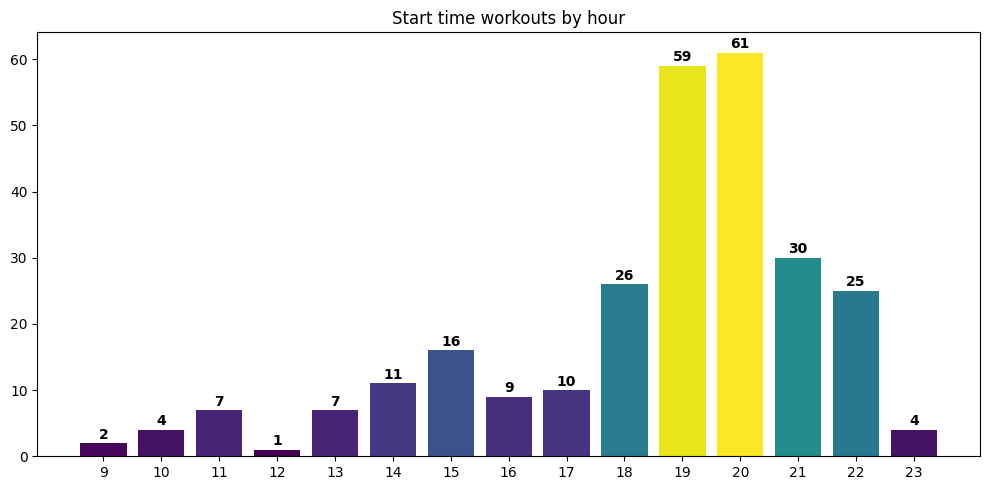

In [448]:
from matplotlib import cm

counts = by_hour['sessions']
norm = plt.Normalize(counts.min(), counts.max())
colors = cm.viridis(norm(counts))

fig, ax = plt.subplots(figsize=(10, 5))  

bars = ax.bar(x=by_hour['hour'], height=by_hour['sessions'], color=colors)
ax.bar_label(bars, padding=1, fontweight="bold")
ax.set_title("Start time workouts by hour")
ax.set_xticks(np.arange(by_hour['hour'].min(), by_hour['hour'].max() + 1, 1))

plt.tight_layout()
plt.show()

### Conclusion